## Geographic Analysis

Do enrollment trends cluster geographically, and what regional patterns emerge?

In [660]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from scipy import stats
from matplotlib.colors import TwoSlopeNorm

In [661]:
enroll_df = pd.read_csv(os.path.dirname(os.getcwd()) + '/data/cleaned_enrollmentdata.csv')

In [662]:
enroll_df.rename(columns={'State or jurisdiction': 'State'}, inplace=True)
enroll_df.head()

,State,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc
0,Alabama,2012-13,216535,130260,86275,34510,49382,21674,24045,518,3145,9884,3917,5967
1,Alabama,2013-14,213669,129045,84624,34615,47519,20808,23295,472,2944,9909,3866,6043
2,Alabama,2014-15,212458,129916,82542,34531,47172,21160,22714,518,2780,10867,4354,6513
3,Alabama,2015-16,212968,131503,81465,34483,44682,20938,21000,436,2308,10826,4593,6233
4,Alabama,2016-17,216115,135080,81035,34923,41893,19891,19627,386,1989,11121,4679,6442


In [663]:
states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan",
    "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia",
    "Wisconsin", "Wyoming", "District of Columbia"
]

state_enrollment = enroll_df[enroll_df["State"].isin(states)]
state_enrollment['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

In [664]:
state_enrollment = state_enrollment.copy()
state_enrollment['Total_Enrollment'] = state_enrollment['Total_Pub_Under'] + state_enrollment['Total_Priv_Under']
state_enrollment.head()

,State,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
0,Alabama,2012-13,216535,130260,86275,34510,49382,21674,24045,518,3145,9884,3917,5967,265917
1,Alabama,2013-14,213669,129045,84624,34615,47519,20808,23295,472,2944,9909,3866,6043,261188
2,Alabama,2014-15,212458,129916,82542,34531,47172,21160,22714,518,2780,10867,4354,6513,259630
3,Alabama,2015-16,212968,131503,81465,34483,44682,20938,21000,436,2308,10826,4593,6233,257650
4,Alabama,2016-17,216115,135080,81035,34923,41893,19891,19627,386,1989,11121,4679,6442,258008


In [665]:
northeast = [
    "Connecticut", "Maine", "Massachusetts", "New Hampshire",
    "New Jersey", "New York", "Pennsylvania", "Rhode Island", "Vermont"
]

midwest = [
    "Illinois", "Indiana", "Iowa", "Kansas", "Michigan", "Minnesota",
    "Missouri", "Nebraska", "North Dakota", "Ohio", "South Dakota",
    "Wisconsin"
]

south = [
    "Alabama", "Arkansas", "Delaware", "Florida", "Georgia", "Kentucky",
    "Louisiana", "Maryland", "Mississippi", "North Carolina", "Oklahoma",
    "South Carolina", "Tennessee", "Texas", "Virginia", "West Virginia"
]

west = [
    "Alaska", "Arizona", "California", "Colorado", "Hawaii", "Idaho",
    "Montana", "Nevada", "New Mexico", "Oregon", "Utah", "Washington",
    "Wyoming"
]

In [666]:
regions = {
    "Northeast": northeast,
    "Midwest": midwest,
    "South": south,
    "West": west
}


In [667]:
northeast_enrollment = state_enrollment[state_enrollment["State"].isin(northeast)]
northeast_enrollment.head()

,State,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
63,Connecticut,2012-13,111481,53253,58228,13471,55331,47176,7883,0,272,21375,20589,786,166812
64,Connecticut,2013-14,109851,52874,56977,13242,56330,47885,8383,0,62,21543,20832,711,166181
65,Connecticut,2014-15,108641,53487,55154,13662,57184,48679,8505,0,0,22441,21717,724,165825
66,Connecticut,2015-16,106337,53576,52761,13429,56722,49154,7568,0,0,23178,22561,617,163059
67,Connecticut,2016-17,103564,53016,50548,13781,57088,49388,7700,0,0,23578,22956,622,160652


In [668]:
southern_enrollment = state_enrollment[state_enrollment["State"].isin(south)]
southern_enrollment.head()

,State,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
0,Alabama,2012-13,216535,130260,86275,34510,49382,21674,24045,518,3145,9884,3917,5967,265917
1,Alabama,2013-14,213669,129045,84624,34615,47519,20808,23295,472,2944,9909,3866,6043,261188
2,Alabama,2014-15,212458,129916,82542,34531,47172,21160,22714,518,2780,10867,4354,6513,259630
3,Alabama,2015-16,212968,131503,81465,34483,44682,20938,21000,436,2308,10826,4593,6233,257650
4,Alabama,2016-17,216115,135080,81035,34923,41893,19891,19627,386,1989,11121,4679,6442,258008


In [669]:
midwest_enrollment = state_enrollment[state_enrollment["State"].isin(midwest)]
midwest_enrollment.head()

,State,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
144,Illinois,2012-13,507197,148467,358730,49940,206514,137447,60339,718,8010,103459,89662,13797,713711
145,Illinois,2013-14,496801,145231,351570,49682,197298,136856,53879,743,5820,99107,86528,12579,694099
146,Illinois,2014-15,480483,144381,336102,48979,195768,136222,53353,735,5458,99750,85694,14056,676251
147,Illinois,2015-16,459770,143615,316155,49334,190820,134754,49923,389,5754,102319,86199,16120,650590
148,Illinois,2016-17,443681,139508,304173,48897,182387,131672,45300,368,5047,102755,86243,16512,626068


In [670]:
western_enrollment = state_enrollment[state_enrollment["State"].isin(west)]
western_enrollment.head()

,State,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
9,Alaska,2012-13,28034,27276,758,2561,1984,497,1259,0,228,218,218,0,30018
10,Alaska,2013-14,29089,27014,2075,2511,3008,429,2191,53,335,282,282,0,32097
11,Alaska,2014-15,27588,26456,1132,2304,4175,372,3256,68,479,264,253,11,31763
12,Alaska,2015-16,26118,25925,193,2275,2694,315,1935,66,378,244,234,10,28812
13,Alaska,2016-17,25146,24958,188,2206,851,348,0,79,424,243,243,0,25997


**sub-question:** Are Northeastern states experiencing different trends than Southern/Western states?


In [671]:
ne_year_trends = northeast_enrollment.groupby("Year").agg({"Total_Enrollment": "sum"}).reset_index()
ne_year_trends.head()

,Year,Total_Enrollment
0,2012-13,2877934
1,2013-14,2862350
2,2014-15,2852403
3,2015-16,2813510
4,2016-17,2780728


In [672]:
s_year_trends = southern_enrollment.groupby("Year").agg({"Total_Enrollment": "sum"}).reset_index()
s_year_trends.head()

,Year,Total_Enrollment
0,2012-13,6133962
1,2013-14,6036847
2,2014-15,5976291
3,2015-16,5906797
4,2016-17,5892357


In [673]:
w_year_trends = western_enrollment.groupby("Year").agg({"Total_Enrollment": "sum"}).reset_index()
w_year_trends.head()

,Year,Total_Enrollment
0,2012-13,4611684
1,2013-14,4562435
2,2014-15,4595443
3,2015-16,4552909
4,2016-17,4527540


In [674]:
mw_year_trends = midwest_enrollment.groupby("Year").agg({"Total_Enrollment": "sum"}).reset_index()
mw_year_trends.head()

,Year,Total_Enrollment
0,2012-13,4045950
1,2013-14,3951046
2,2014-15,3805782
3,2015-16,3698222
4,2016-17,3604595


In [675]:
fig = go.Figure()

# Northeast
fig.add_trace(go.Scatter(
    x=ne_year_trends['Year'],
    y=ne_year_trends['Total_Enrollment'],
    mode='lines+markers',
    name='Northeast'
))

# Southeast
fig.add_trace(go.Scatter(
    x=s_year_trends['Year'],
    y=s_year_trends['Total_Enrollment'],
    mode='lines+markers',
    name='Southeast'
))

# West
fig.add_trace(go.Scatter(
    x=w_year_trends['Year'],
    y=w_year_trends['Total_Enrollment'],
    mode='lines+markers',
    name='West'
))

fig.add_trace(go.Scatter(
    x=mw_year_trends['Year'],
    y=mw_year_trends['Total_Enrollment'],
    mode='lines+markers',
    name='Midwest'
))

fig.update_layout(
    title="Total Enrollment by Region",
    xaxis_title="Year",
    yaxis_title="Total Enrollment",
    legend_title="Region"
)

fig.show()

From the appearance of this graph it would seem like the trends all mirror eachother regardless of region.

In [676]:
ne_baseline = ne_year_trends[ne_year_trends['Year'] == '2012-13']['Total_Enrollment'].values[0]
s_baseline = s_year_trends[s_year_trends['Year'] == '2012-13']['Total_Enrollment'].values[0]
w_baseline = w_year_trends[w_year_trends['Year'] == '2012-13']['Total_Enrollment'].values[0]
mw_baseline = mw_year_trends[mw_year_trends['Year'] == '2012-13']['Total_Enrollment'].values[0]

print(f"Northeast Baseline: {ne_baseline}")
print(f"Southeast Baseline: {s_baseline}")
print(f"West Baseline: {w_baseline}")
print(f"Midwest Baseline: {mw_baseline}")

Northeast Baseline: 2877934
Southeast Baseline: 6133962
West Baseline: 4611684
Midwest Baseline: 4045950


In [677]:
ne_year_trends

,Year,Total_Enrollment
0,2012-13,2877934
1,2013-14,2862350
2,2014-15,2852403
3,2015-16,2813510
4,2016-17,2780728
5,2017-18,2760260
6,2018-19,2727334
7,2019-20,2696130
8,2020-21,2582373
9,2021-22,2505320


In [678]:
ne_slope, ne_intercept, ne_r_value, ne_p_value, ne_std_err = stats.linregress(np.arange(len(ne_year_trends['Year'])), ne_year_trends['Total_Enrollment'])
print(f"Northeast Slope: {ne_slope}")
print(f"Northeast Intercept: {ne_intercept}")
print(f"Northeast R-squared: {ne_r_value**2}")
print(f"Northeast P-value: {ne_p_value}")
print(f"Northeast Standard Error: {ne_std_err}")

Northeast Slope: -38628.64242424243
Northeast Intercept: 2919663.0909090913
Northeast R-squared: 0.9067226254914476
Northeast P-value: 2.1520246405552484e-05
Northeast Standard Error: 4380.416258681408


In [679]:
ne_year_trends['eindex'] = (ne_year_trends['Total_Enrollment']/ ne_baseline)*100

In [680]:
##Baseline
ne_slope, ne_intercept, ne_r_value, ne_p_value, ne_std_err = stats.linregress(np.arange(len(ne_year_trends['Year'])), ne_year_trends['eindex'])
print(f"Northeast Slope: {ne_slope}")
print(f"Northeast Intercept: {ne_intercept}")
print(f"Northeast R-squared: {ne_r_value**2}")
print(f"Northeast P-value: {ne_p_value}")
print(f"Northeast Standard Error: {ne_std_err}")

Northeast Slope: -1.3422351737128946
Northeast Intercept: 101.44996691755583
Northeast R-squared: 0.9067226254914471
Northeast P-value: 2.1520246405552907e-05
Northeast Standard Error: 0.15220697412384793


In [681]:
px.scatter(ne_year_trends, x=np.arange(len(ne_year_trends['Year'].unique())), y='eindex', trendline="ols")

In [682]:
s_slope, s_intercept, s_r_value, s_p_value, s_std_err = stats.linregress(np.arange(len(s_year_trends['Year'])), s_year_trends['Total_Enrollment'])
print(f"South Slope: {s_slope}")
print(f"South Intercept: {s_intercept}")
print(f"South R-squared: {s_r_value**2}")
print(f"South P-value: {s_p_value}")
print(f"South Standard Error: {s_std_err}")

South Slope: -52915.69696969697
South Intercept: 6116998.036363637
South R-squared: 0.8244967400029993
South P-value: 0.00027991586150859156
South Standard Error: 8631.527326558591


In [683]:
s_year_trends['eindex'] = (s_year_trends['Total_Enrollment']/ s_baseline)*100

In [684]:
s_slope, s_intercept, s_r_value, s_p_value, s_std_err = stats.linregress(np.arange(len(s_year_trends['Year'])), s_year_trends['eindex'])
print(f"South Slope: {s_slope}")
print(f"South Intercept: {s_intercept}")
print(f"South R-squared: {s_r_value**2}")
print(f"South P-value: {s_p_value}")
print(f"South Standard Error: {s_std_err}")

South Slope: -0.8626675054344477
South Intercept: 99.72344198356032
South R-squared: 0.8244967400030001
South P-value: 0.0002799158615085862
South Standard Error: 0.14071700031005355


In [685]:
px.scatter(s_year_trends, x=np.arange(len(s_year_trends['Year'].unique())), y='eindex', trendline="ols")

In [686]:
w_slope, w_intercept, w_r_value, w_p_value, w_std_err = stats.linregress(np.arange(len(w_year_trends['Year'])), w_year_trends['Total_Enrollment'])
print(f"West Slope: {w_slope}")
print(f"West Intercept: {w_intercept}")
print(f"West R-squared: {w_r_value**2}")
print(f"West P-value: {w_p_value}")
print(f"West Standard Error: {w_std_err}")

West Slope: -36331.35151515152
West Intercept: 4656363.981818182
West R-squared: 0.6514671000917855
West P-value: 0.004761800512824026
West Standard Error: 9395.333619167748


In [687]:
w_year_trends['eindex'] = (w_year_trends['Total_Enrollment']/ w_baseline)*100

In [688]:
w_slope, w_intercept, w_r_value, w_p_value, w_std_err = stats.linregress(np.arange(len(w_year_trends['Year'])), w_year_trends['eindex'])
print(f"West Slope: {w_slope}")
print(f"West Intercept: {w_intercept}")
print(f"West R-squared: {w_r_value**2}")
print(f"West P-value: {w_p_value}")
print(f"West Standard Error: {w_std_err}")

West Slope: -0.7878109496477106
West Intercept: 100.96884309111772
West R-squared: 0.6514671000917853
West P-value: 0.004761800512824031
West Standard Error: 0.2037289115899475


In [689]:
px.scatter(w_year_trends, x=np.arange(len(w_year_trends['Year'].unique())), y='eindex', trendline="ols")

In [690]:
mw_year_trends['eindex'] = (mw_year_trends['Total_Enrollment']/ mw_baseline)*100

In [691]:
mw_slope, mw_intercept, mw_r_value, mw_p_value, mw_std_err = stats.linregress(np.arange(len(mw_year_trends['Year'])), mw_year_trends['eindex'])
print(f"West Slope: {mw_slope}")
print(f"West Intercept: {mw_intercept}")
print(f"West R-squared: {mw_r_value**2}")
print(f"West P-value: {mw_p_value}")
print(f"West Standard Error: {mw_std_err}")

West Slope: -2.3928844669585416
West Intercept: 99.27671105448884
West R-squared: 0.9901667106074328
West P-value: 2.5666624371901345e-09
West Standard Error: 0.08430862117946912


In [692]:
px.scatter(mw_year_trends, x=np.arange(len(mw_year_trends['Year'].unique())), y='eindex', trendline="ols")

In [693]:
p_values = [ne_p_value, s_p_value, w_p_value, mw_p_value]

for p_value in p_values:
    if p_value < 0.05:
        print("The null hypothesis can be rejected")
    else:
        print("The null hypothesis cannot be rejected")

The null hypothesis can be rejected
The null hypothesis can be rejected
The null hypothesis can be rejected
The null hypothesis can be rejected


This test shows that all of the negative trends are statistically significant at the 0.05 level.

In [694]:
ne_changes = northeast_enrollment.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())
s_changes = southern_enrollment.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())
w_changes = western_enrollment.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())
m_changes = midwest_enrollment.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())

# print(ne_changes)
# print(s_changes)
# print(w_changes)
# print(m_changes)

f_stat, p_value = stats.f_oneway(ne_changes, s_changes, w_changes, m_changes)
print(f"ANOVA p-value: {p_value}")

ANOVA p-value: 0.24772554498006544


In [695]:
print(f"Northeast Slope: {ne_slope}")
print(f"South Slope: {s_slope}")
print(f"West Slope: {w_slope}")
print(f"Midwest Slope: {mw_slope}")

Northeast Slope: -1.3422351737128946
South Slope: -0.8626675054344477
West Slope: -0.7878109496477106
Midwest Slope: -2.3928844669585416


From this we can see that the northeast enrollment has the steepest decline considering their 2012-13 date as a baseline. The south has the next steepest decline. The west has the slowest decline. However if the anova value of 0.25 is to be believed then the trends are not statistically different.

**sub-question:** Is there spatial autocorrelation in enrollment trends? (Do neighboring states behave similarly?)


In [696]:
import json

state_dict = json.load(open('state_neighbors.json'))


In [697]:
state_trend = state_enrollment[state_enrollment['State'] == 'Alabama'].groupby('Year').sum().reset_index()

state_trend

,Year,State,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
0,2012-13,Alabama,216535,130260,86275,34510,49382,21674,24045,518,3145,9884,3917,5967,265917
1,2013-14,Alabama,213669,129045,84624,34615,47519,20808,23295,472,2944,9909,3866,6043,261188
2,2014-15,Alabama,212458,129916,82542,34531,47172,21160,22714,518,2780,10867,4354,6513,259630
3,2015-16,Alabama,212968,131503,81465,34483,44682,20938,21000,436,2308,10826,4593,6233,257650
4,2016-17,Alabama,216115,135080,81035,34923,41893,19891,19627,386,1989,11121,4679,6442,258008
5,2017-18,Alabama,217755,137019,80736,36316,41807,21369,18677,0,1761,10944,4780,6164,259562
6,2018-19,Alabama,217610,137380,80230,37477,37784,21155,16523,0,106,11311,5106,6205,255394
7,2019-20,Alabama,216326,136404,79922,38477,36888,20225,16126,0,537,11339,5322,6017,253214
8,2020-21,Alabama,204632,133781,70851,41865,34753,19125,15077,0,551,10931,5388,5543,239385
9,2021-22,Alabama,207241,131801,75440,42939,32151,18116,13201,295,539,10429,5478,4951,239392


In [698]:
for state, neighbors in state_dict.items():
    state_trend = state_enrollment[state_enrollment['State'] == state].groupby('Year').sum().reset_index()
    state_baseline = state_trend[state_trend['Year'] == '2012-13']['Total_Enrollment'].values[0]
    state_trend['eindex'] = (state_trend['Total_Enrollment']/ state_baseline)*100
    
    state_slope, state_intercept, state_r_value, state_p_value, state_std_err = stats.linregress(np.arange(len(state_trend['Year'])), state_trend['eindex'])
    state_dict[state]['slope'] = state_slope
    state_dict[state]['intercept'] = state_intercept
    state_dict[state]['r_value'] = state_r_value
    state_dict[state]['p_value'] = state_p_value
    state_dict[state]['std_err'] = state_std_err

    if state_p_value < 0.05:
        state_dict[state]['sig'] = True
    else:
        state_dict[state]['sig'] = False

In [699]:
state_dict['Alabama']

{'neighbors': ['Florida', 'Georgia', 'Mississippi', 'Tennessee'],
 'slope': np.float64(-0.9769282076054494),
 'intercept': np.float64(100.26594080791443),
 'r_value': np.float64(-0.8877080240535666),
 'p_value': np.float64(0.0006062015452915853),
 'std_err': np.float64(0.17913864438786797),
 'sig': True}

In [700]:
for state, vals in state_dict.items():
    neighbors = vals['neighbors']
    neighbor_slopes = [
        state_dict[n]['slope']
        for n in neighbors
        if state_dict[n]['sig'] is True
    ]
    if len(neighbor_slopes) == 0:
        vals['signed_neighbor_index'] = np.nan
    else:
        neighbor_avg = np.mean(neighbor_slopes)
        vals['signed_neighbor_index'] = vals['slope'] - neighbor_avg



In [701]:
state_dict['Alabama']

{'neighbors': ['Florida', 'Georgia', 'Mississippi', 'Tennessee'],
 'slope': np.float64(-0.9769282076054494),
 'intercept': np.float64(100.26594080791443),
 'r_value': np.float64(-0.8877080240535666),
 'p_value': np.float64(0.0006062015452915853),
 'std_err': np.float64(0.17913864438786797),
 'sig': True,
 'signed_neighbor_index': np.float64(0.2835207852733451)}

In [702]:
map_dict = state_dict.copy()
map_dict.pop('Alaska')
map_dict.pop('Hawaii')

{'neighbors': [],
 'slope': np.float64(-2.7969147532607512),
 'intercept': np.float64(98.41155812659451),
 'r_value': np.float64(-0.968237120644961),
 'p_value': np.float64(4.2855555432460574e-06),
 'std_err': np.float64(0.2553589883599495),
 'sig': True,
 'signed_neighbor_index': nan}

In [703]:
import geopandas as gpd


states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

In [704]:
df = (
    pd.DataFrame.from_dict(state_dict, orient='index')
      .reset_index()
      .rename(columns={'index': 'state'})
)

gdf = states.merge(df, left_on='name', right_on='state', how='left').dropna()
gdf.head()

,id,name,density,geometry,state,neighbors,slope,intercept,r_value,p_value,std_err,sig,signed_neighbor_index
0,01,Alabama,94.65,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",Alabama,"[Florida, Georgia, Mississippi, Tennessee]",-0.976928,100.265941,-0.887708,6.062015e-04,0.179139,True,0.283521
2,04,Arizona,57.05,"POLYGON ((-109.0425 37.00026, -109.04798 31.33...",Arizona,"[California, Colorado, New Mexico, Nevada, Utah]",-2.126646,94.690029,-0.871842,1.008215e-03,0.422395,True,-2.794226
3,05,Arkansas,56.43,"POLYGON ((-94.47384 36.50186, -90.15254 36.496...",Arkansas,"[Louisiana, Missouri, Mississippi, Oklahoma, T...",-2.131879,100.515335,-0.983534,3.152849e-07,0.138497,True,-0.322792
4,06,California,241.70,"POLYGON ((-123.23326 42.00619, -122.37885 42.0...",California,"[Arizona, Nevada, Oregon]",-0.668767,103.267797,-0.556455,9.480298e-02,0.353050,False,1.679821
5,08,Colorado,49.33,"POLYGON ((-107.91973 41.00391, -105.72895 40.9...",Colorado,"[Arizona, Kansas, Nebraska, New Mexico, Oklaho...",-0.224448,98.312281,-0.321642,3.647909e-01,0.233606,False,0.843731


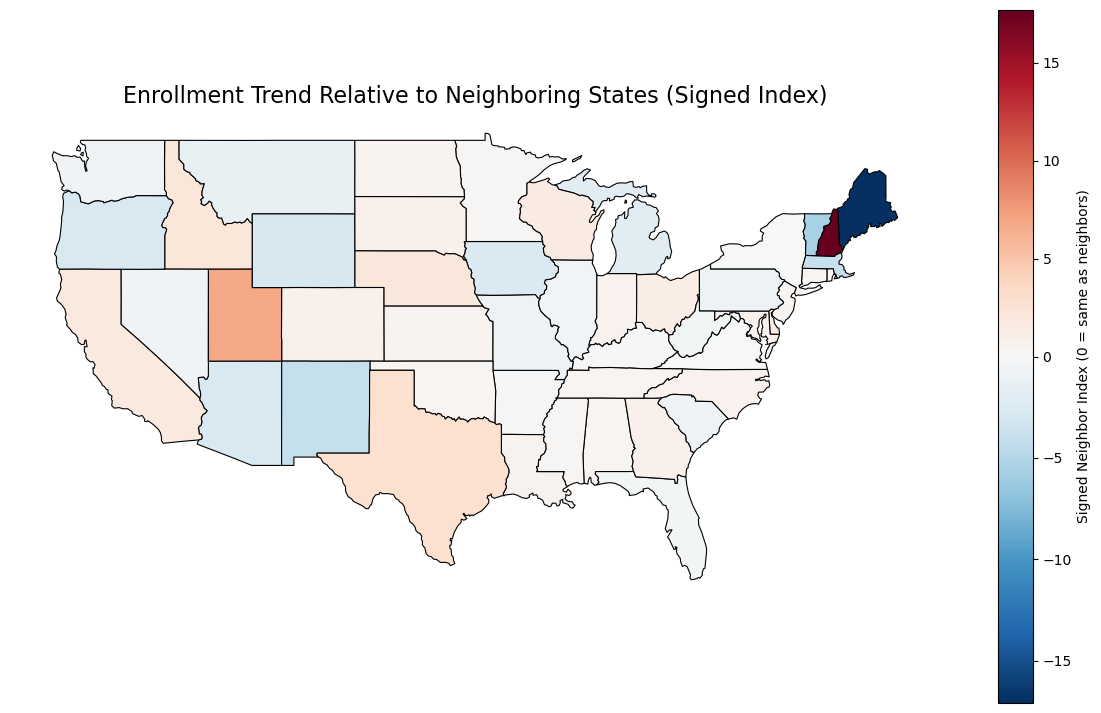

In [705]:
index_series = gdf['signed_neighbor_index'].dropna()
vmin = index_series.min()
vmax = index_series.max()
vcenter = 0.0  # 0 = same as neighbors

norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

# 6️⃣ Plot
fig, ax = plt.subplots(1, 1, figsize=(15, 9))
gdf.plot(
    column='signed_neighbor_index',
    cmap='RdBu_r',
    linewidth=0.8,
    ax=ax,
    edgecolor='black',
    norm=norm,
    missing_kwds={"color": "lightgrey", "label": "No comparison"}
)
ax.set_title("Enrollment Trend Relative to Neighboring States (Signed Index)", fontsize=16)
ax.axis('off')

# 7️⃣ Colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Signed Neighbor Index (0 = same as neighbors)")

plt.show()

This shows the map of the us with their trends relative to their neighbhors. The darker the blue the faster the decline relative to its neighbors.

Statistical test: Morans statistic

In [706]:
from esda.moran import Moran
from libpysal.weights import W

In [707]:
# Convert your state_neighbors.json to spatial weights
neighbors = state_dict  # Your existing dict

neighbors.pop('Alaska')
neighbors.pop('Hawaii')
# Create weights matrix
w_dict = {state: vals['neighbors'] for state, vals in neighbors.items()}
w = W(w_dict)

w

In [708]:
state_slopes = [state_dict[state]['slope'] for state in w_dict.keys()]


In [709]:
moran = Moran(state_slopes, w)

print(f"Moran's I: {moran.I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")
print(f"Interpretation: {'Significant spatial clustering' if moran.p_sim < 0.05 else 'No spatial clustering'}")

Moran's I: 0.0329
P-value: 0.1580
Interpretation: No spatial clustering


**Question:** Is there spatial autocorrelation in enrollment trends? (Do neighboring states behave similarly?)

**Answer:** All states perform relatively similarly to their neighbors. However as expected the states that are surrounded by faster declining states can appear to be performing better than the reality and then the Moran's I value is not significant further proving it.


**sub-question:** Are urban vs mixed vs rural states showing different patterns?


For this data we designated a state as Urban if over 70% of the population is Urban, mixed if 40-70% and rural if less than 40%.

In [710]:
urb_rur_df = pd.read_csv(os.path.dirname(os.getcwd()) + '/data/rural_urban_pop.csv', ).T.reset_index()

In [711]:
urb_rur_df.head()

,index,0,1,2,3
0,Label (Grouping),Total:,Urban,Rural,Not defined for this file
1,Alabama,"5,024,279","2,900,880","2,123,399",0
2,Alaska,"733,391","475,967","257,424",0
3,Arizona,"7,151,502","6,385,230","766,272",0
4,Arkansas,"3,011,524","1,670,677","1,340,847",0


In [712]:
urb_rur_df.columns = ['State', 'Total', 'Urban', 'Rural', 'Not defined for this file']
urb_rur_df.drop(0, inplace=True)


In [713]:
urb_rur_df.head()

,State,Total,Urban,Rural,Not defined for this file
1,Alabama,"5,024,279","2,900,880","2,123,399",0
2,Alaska,"733,391","475,967","257,424",0
3,Arizona,"7,151,502","6,385,230","766,272",0
4,Arkansas,"3,011,524","1,670,677","1,340,847",0
5,California,"39,538,223","37,259,490","2,278,733",0


In [714]:
urb_rur_df['Total'] = urb_rur_df['Total'].str.replace(',', '').astype(int)
urb_rur_df['Urban'] = urb_rur_df['Urban'].str.replace(',', '').astype(int)
urb_rur_df['Rural'] = urb_rur_df['Rural'].str.replace(',', '').astype(int)

In [715]:
r = urb_rur_df['Urban'] / urb_rur_df['Total']
map = r.map(lambda x: 'Urban' if x > 0.7 else 'Rural' if x < 0.4 else 'Mixed')
urb_rur_df['desig'] = map

In [716]:
merged = pd.merge(urb_rur_df, state_enrollment, how='left', on='State')
merged.drop(columns= ['Not defined for this file'], inplace=True)
merged.head()

,State,Total,Urban,Rural,desig,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
0,Alabama,5024279,2900880,2123399,Mixed,2012-13,216535.0,130260.0,86275.0,34510.0,49382.0,21674.0,24045.0,518.0,3145.0,9884.0,3917.0,5967.0,265917.0
1,Alabama,5024279,2900880,2123399,Mixed,2013-14,213669.0,129045.0,84624.0,34615.0,47519.0,20808.0,23295.0,472.0,2944.0,9909.0,3866.0,6043.0,261188.0
2,Alabama,5024279,2900880,2123399,Mixed,2014-15,212458.0,129916.0,82542.0,34531.0,47172.0,21160.0,22714.0,518.0,2780.0,10867.0,4354.0,6513.0,259630.0
3,Alabama,5024279,2900880,2123399,Mixed,2015-16,212968.0,131503.0,81465.0,34483.0,44682.0,20938.0,21000.0,436.0,2308.0,10826.0,4593.0,6233.0,257650.0
4,Alabama,5024279,2900880,2123399,Mixed,2016-17,216115.0,135080.0,81035.0,34923.0,41893.0,19891.0,19627.0,386.0,1989.0,11121.0,4679.0,6442.0,258008.0


In [717]:
rural_df = merged[merged['desig'] == 'Rural']
urban_df = merged[merged['desig'] == 'Urban']
mixed_df = merged[merged['desig'] == 'Mixed']

In [718]:
mixed_df.head()

,State,Total,Urban,Rural,desig,Year,Total_Pub_Under,4y_Pub_Under,2y_Pub_Under,Total_Pub_Postbacc,Total_Priv_Under,Np_4y_Priv_Under,Fp_4y_Priv_Under,Np_2y_Priv_Under,Fp_2y_Priv_Under,Total_Priv_Postbacc,Np_4y_Priv_Postbacc,Fp_4y_Priv_Postbacc,Total_Enrollment
0,Alabama,5024279,2900880,2123399,Mixed,2012-13,216535.0,130260.0,86275.0,34510.0,49382.0,21674.0,24045.0,518.0,3145.0,9884.0,3917.0,5967.0,265917.0
1,Alabama,5024279,2900880,2123399,Mixed,2013-14,213669.0,129045.0,84624.0,34615.0,47519.0,20808.0,23295.0,472.0,2944.0,9909.0,3866.0,6043.0,261188.0
2,Alabama,5024279,2900880,2123399,Mixed,2014-15,212458.0,129916.0,82542.0,34531.0,47172.0,21160.0,22714.0,518.0,2780.0,10867.0,4354.0,6513.0,259630.0
3,Alabama,5024279,2900880,2123399,Mixed,2015-16,212968.0,131503.0,81465.0,34483.0,44682.0,20938.0,21000.0,436.0,2308.0,10826.0,4593.0,6233.0,257650.0
4,Alabama,5024279,2900880,2123399,Mixed,2016-17,216115.0,135080.0,81035.0,34923.0,41893.0,19891.0,19627.0,386.0,1989.0,11121.0,4679.0,6442.0,258008.0


In [719]:
urban_df = urban_df.drop(510)

In [720]:
urb_changes = urban_df.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())
rur_changes = rural_df.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())
mix_changes = mixed_df.groupby('State')['Total_Enrollment'].apply(lambda x: x.pct_change().mean())

# print(urb_changes)
# print(rur_changes)
# print(mix_changes)

f_stat, p_value = stats.f_oneway(urb_changes, rur_changes, mix_changes)
print(f"ANOVA p-value: {p_value}")

ANOVA p-value: 0.9395264975711706


**Question:** Are urban vs mixed vs rural states showing different patterns?

**Answer:** There is no significant difference between rural, mixed and urban states.

**sub-question:** Which Census regions/divisions show the strongest declines?

In [721]:
ne_division = ['Connecticut', 'Maine', 'Massachusetts','New Hampshire', 'Rhode Island','Vermont']
mid_atlantic = ['New Jersey', 'New York', 'Pennsylvania']
e_north_cent = ['Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin']
w_north_cent = ['Iowa', 'Kansas', 'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 'South Dakota']
south_atlantic = ['Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Maryland', 'North Carolina', 'South Carolina', 'Virginia', 'West Virginia']
east_south_central = ['Alabama', 'Kentucky', 'Mississippi', 'Tennessee']
west_south_central = ['Arkansas', 'Louisiana', 'Oklahoma','Texas']
mountain = ['Arizona', 'Colorado', 'Idaho', 'Montana', 'Nevada', 'New Mexico', 'Utah', 'Wyoming']
pacific = ['Alaska', 'California', 'Hawaii', 'Oregon', 'Washington']

In [722]:
divisions = [ne_division, mid_atlantic, e_north_cent, w_north_cent, south_atlantic, east_south_central, west_south_central, mountain, pacific]

In [723]:
div_changes = {}

for i, div in enumerate(divisions):
    # Filter enrollment for the states in this division
    df_div = state_enrollment[state_enrollment['State'].isin(div)]
    
    # Compute average yearly percent change per state
    changes = (
        df_div.groupby('State')['Total_Enrollment']
        .apply(lambda x: x.pct_change().dropna().mean())
        .dropna()
    )
    
    # Store results in dictionary
    div_changes[f"Division_{i+1}"] = changes
    
    # Optional: ANOVA if you have multiple subgroups within the division
    # Example: comparing Urban vs Rural vs Mixed inside this division
    #f_stat, p_value = stats.f_oneway(urb_changes, rur_changes, mix_changes)
    
    
    # print(f"ANOVA p-value: {p_value}")  # Only compute if comparing groups

In [724]:
f_stat, p_value = stats.f_oneway(div_changes['Division_1'], div_changes['Division_2'], div_changes['Division_3'], div_changes['Division_4'], div_changes['Division_5'], div_changes['Division_6'], div_changes['Division_7'], div_changes['Division_8'], div_changes['Division_9'])
print(f"ANOVA p-value: {p_value}")

ANOVA p-value: 0.30222041072658085


There is no significant different in the trends between the 9 regions of census data. Overall this shows that the country is experiencing an overall decline in enrollment overall.